# Chatbot with Collection Schema 

## Review

우리는 챗봇을 확장하여 의미적 기억을 단일 [사용자 프로필](https://docs.langchain.com/oss/python/concepts/memory#profile)에 저장하도록 했습니다.

또한 이 스키마를 새로운 정보로 업데이트하기 위한 라이브러리인 [Trustcall](https://github.com/hinthornw/trustcall)을 도입했습니다. 

## Goals

때로는 단일 프로필이 아닌 [컬렉션](https://docs.google.com/presentation/d/181mvjlgsnxudQI6S3ritg9sooNyu4AcLLFH1UK0kIuk/edit#slide=id.g30eb3c8cf10_0_200)에 추억을 저장하고 싶을 때가 있습니다. 

여기서는 채팅봇을 업데이트하여 [memory를 컬렉션에 저장](https://docs.langchain.com/oss/python/concepts/memory#collection)하는 방법을 알아봅니다.

또한 Trustcall을 사용하여 이 컬렉션을 업데이트하는 방법도 보여드리겠습니다. 


In [1]:
# %%capture --no-stderr
# %pip install -U langchain_openai langgraph trustcall langchain_core

In [2]:
# import os, getpass

# def _set_env(var: str):
#     # Check if the variable is set in the OS environment
#     env_value = os.environ.get(var)
#     if not env_value:
#         # If not set, prompt the user for input
#         env_value = getpass.getpass(f"{var}: ")
    
#     # Set the environment variable for the current process
#     os.environ[var] = env_value

# _set_env("LANGSMITH_API_KEY")
# os.environ["LANGSMITH_TRACING"] = "true"
# os.environ["LANGSMITH_PROJECT"] = "langchain-academy"

from dotenv import load_dotenv

load_dotenv("../../.env")

True

## Defining a collection schema

사용자 정보를 고정된 프로필 구조에 저장하는 대신, 사용자 상호작용에 대한 기억을 저장하기 위해 유연한 컬렉션 스키마를 생성할 것입니다.

각 기억은 별도의 항목으로 저장되며, 기억하고자 하는 주요 정보를 담는 단일 `content` 필드를 갖습니다.

이 접근 방식은 사용자에 대해 더 많이 알아갈수록 성장하고 변화할 수 있는 개방형 기억 컬렉션을 구축할 수 있게 합니다.

컬렉션 스키마는 [Pydantic](https://docs.pydantic.dev/latest/) 객체로 정의할 수 있습니다. 

In [3]:
from pydantic import BaseModel, Field

class Memory(BaseModel):
    content: str = Field(description="The main content of the memory. For example: User expressed interest in learning about French.")

class MemoryCollection(BaseModel):
    memories: list[Memory] = Field(description="A list of memories about the user.")

In [4]:
# _set_env("OPENAI_API_KEY")

We can used LangChain's chat model  [chat model](https://docs.langchain.com/oss/python/langchain/models) interface's [`with_structured_output`](https://docs.langchain.com/oss/python/langchain/models#structured-outputs) method to enforce structured output.

In [5]:
from langchain_core.messages import HumanMessage
from langchain_openai import ChatOpenAI

# Initialize the model
model = ChatOpenAI(model="gpt-4o", temperature=0)

# Bind schema to model
model_with_structure = model.with_structured_output(MemoryCollection)

# Invoke the model to produce structured output that matches the schema
memory_collection = model_with_structure.invoke([HumanMessage("내 이름은 유광명이고 테니스 치는 것을 좋아해요.")])
memory_collection.memories

/Users/kmyu/Desktop/project/langchain-study/langchain-academy/intro-to-langgraph/.venv/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=MemoryCollection(memories...joys playing tennis.')]), input_type=MemoryCollection])
  return self.__pydantic_serializer__.to_python(


[Memory(content="User's name is 유광명."),
 Memory(content='User enjoys playing tennis.')]

`model_dump()`를 사용하여 Pydantic 모델 인스턴스를 Python 사전으로 직렬화할 수 있습니다.

In [6]:
memory_collection.memories[0].model_dump()

{'content': "User's name is 유광명."}

각 메모리의 사전 표현을 저장소에 저장합니다. 

In [7]:
import uuid
from langgraph.store.memory import InMemoryStore

# Initialize the in-memory store
in_memory_store = InMemoryStore()

# Namespace for the memory to save
user_id = "1"
namespace_for_memory = (user_id, "memories")

# Save a memory to namespace as key and value
key = str(uuid.uuid4())
value = memory_collection.memories[0].model_dump()
in_memory_store.put(namespace_for_memory, key, value)

key = str(uuid.uuid4())
value = memory_collection.memories[1].model_dump()
in_memory_store.put(namespace_for_memory, key, value)

Search for memories in the store. 

In [8]:
# Search 
for m in in_memory_store.search(namespace_for_memory):
    print(m.dict())

{'namespace': ['1', 'memories'], 'key': '7e314d79-0d0f-4f81-83d8-797a158697e5', 'value': {'content': "User's name is 유광명."}, 'created_at': '2026-03-02T23:51:16.678824+00:00', 'updated_at': '2026-03-02T23:51:16.678827+00:00', 'score': None}
{'namespace': ['1', 'memories'], 'key': 'a9d9ad29-241b-4a83-ad21-e0f7769a399f', 'value': {'content': 'User enjoys playing tennis.'}, 'created_at': '2026-03-02T23:51:16.678899+00:00', 'updated_at': '2026-03-02T23:51:16.678900+00:00', 'score': None}


## Updating collection schema

지난 강의에서 프로필 스키마 업데이트의 어려움을 논의했습니다.

컬렉션에도 동일한 문제가 적용됩니다!

컬렉션에 새로운 기억을 추가할 수 있을 뿐만 아니라 기존 기억도 업데이트할 수 있는 기능이 필요합니다.

이제 [Trustcall](https://github.com/hinthornw/trustcall)을 사용해 컬렉션을 업데이트하는 방법도 보여드리겠습니다. 

이를 통해 새로운 메모리를 추가할 수 있을 뿐만 아니라 [컬렉션 내 기존 메모리를 업데이트](https://github.com/hinthornw/trustcall?tab=readme-ov-file#simultanous-updates--insertions
)할 수도 있습니다.

Trustcall을 사용해 새로운 추출기를 정의해 보겠습니다.

이전과 마찬가지로 각 메모리(`Memory`)에 대한 스키마를 제공합니다.

하지만 `enable_inserts=True`를 지정하면 추출기가 컬렉션에 새 메모리를 삽입할 수 있습니다. 

In [9]:
from trustcall import create_extractor

# Create the extractor
trustcall_extractor = create_extractor(
    model,
    tools=[Memory],
    tool_choice="Memory",
    enable_inserts=True,
)

In [10]:
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage

# Instruction
instruction = """Extract memories from the following conversation:"""

# Conversation
conversation = [HumanMessage(content="안녕, 내이름은 유광명이야."), 
                AIMessage(content="반가워요. 광명님."), 
                HumanMessage(content="오늘 아침 나는 송파구에서 멋지게 테니스를 쳤어.")]

# Invoke the extractor
result = trustcall_extractor.invoke({"messages": [SystemMessage(content=instruction)] + conversation})

In [11]:
# Messages contain the tool calls
for m in result["messages"]:
    m.pretty_print()

================================== Ai Message ==================================
Tool Calls:
  Memory (call_W00ds2Wwx1u0OCQjhLuzl2SO)
 Call ID: call_W00ds2Wwx1u0OCQjhLuzl2SO
  Args:
    content: User, named 유광명, played tennis in Songpa-gu this morning.


In [12]:
# Responses contain the memories that adhere to the schema
for m in result["responses"]: 
    print(m)

content='User, named 유광명, played tennis in Songpa-gu this morning.'


In [13]:
# Metadata contains the tool call  
for m in result["response_metadata"]: 
    print(m)

{'id': 'call_W00ds2Wwx1u0OCQjhLuzl2SO'}


In [14]:
# Update the conversation
updated_conversation = [AIMessage(content="좋네요. 그뒤에 뭐하셨어요?"), 
                        HumanMessage(content="빵집에 가서 크로와상을 먹었어."),                        
                        AIMessage(content="그외에 생각하는 것 있어요?"),
                        HumanMessage(content="일본에 대해서 생각하고 있었어, 이번 겨울에 가려구!"),]

# Update the instruction
system_msg = """Update existing memories and create new ones based on the following conversation:"""

# We'll save existing memories, giving them an ID, key (tool name), and value
tool_name = "Memory"
existing_memories = [(str(i), tool_name, memory.model_dump()) for i, memory in enumerate(result["responses"])] if result["responses"] else None
existing_memories

[('0',
  'Memory',
  {'content': 'User, named 유광명, played tennis in Songpa-gu this morning.'})]

In [15]:
# Invoke the extractor with our updated conversation and existing memories
result = trustcall_extractor.invoke({"messages": updated_conversation, 
                                     "existing": existing_memories})

In [16]:
# Messages from the model indicate two tool calls were made
for m in result["messages"]:
    m.pretty_print()

================================== Ai Message ==================================
Tool Calls:
  Memory (call_lXFc0yD4xJg6HmecPF3OlY0T)
 Call ID: call_lXFc0yD4xJg6HmecPF3OlY0T
  Args:
    content: User, named 유광명, played tennis in Songpa-gu this morning. Then, went to a bakery and ate a croissant. User was also thinking about going to Japan this winter.
  Memory (call_qoqMk7hmEjK4hvezgBIlf8Fb)
 Call ID: call_qoqMk7hmEjK4hvezgBIlf8Fb
  Args:
    content: User went to a bakery and ate a croissant. User was also thinking about going to Japan this winter.


In [17]:
# Responses contain the memories that adhere to the schema
for m in result["responses"]: 
    print(m)

content='User, named 유광명, played tennis in Songpa-gu this morning. Then, went to a bakery and ate a croissant. User was also thinking about going to Japan this winter.'
content='User went to a bakery and ate a croissant. User was also thinking about going to Japan this winter.'


이는 `json_doc_id`를 지정하여 컬렉션의 첫 번째 메모리를 업데이트했음을 알려줍니다. 

In [18]:
# Metadata contains the tool call  
for m in result["response_metadata"]: 
    print(m)

{'id': 'call_lXFc0yD4xJg6HmecPF3OlY0T', 'json_doc_id': '0'}
{'id': 'call_qoqMk7hmEjK4hvezgBIlf8Fb'}


LangSmith trace: 

https://smith.langchain.com/public/ebc1cb01-f021-4794-80c0-c75d6ea90446/r

## Chatbot with collection schema updating

Now, let's bring Trustcall into our chatbot to create and update a memory collection.

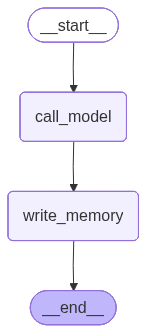

In [19]:
from IPython.display import Image, display

import uuid

from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.store.memory import InMemoryStore
from langchain_core.messages import merge_message_runs
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.runnables.config import RunnableConfig
from langgraph.checkpoint.memory import MemorySaver
from langgraph.store.base import BaseStore

# Initialize the model
model = ChatOpenAI(model="gpt-4o", temperature=0)

# Memory schema
class Memory(BaseModel):
    content: str = Field(description="The main content of the memory. For example: User expressed interest in learning about French.")

# Create the Trustcall extractor
trustcall_extractor = create_extractor(
    model,
    tools=[Memory],
    tool_choice="Memory",
    # This allows the extractor to insert new memories
    enable_inserts=True,
)

# Chatbot instruction
MODEL_SYSTEM_MESSAGE = """당신은 유용한 챗봇입니다. 사용자의 동반자가 되도록 설계되었습니다.

당신은 장기 기억을 가지고 있어 시간이 지남에 따라 사용자에 대해 학습한 정보를 추적합니다.

현재 기억 (이번 대화에서 업데이트된 기억을 포함할 수 있음): 

{memory}"""

# Trustcall instruction
TRUSTCALL_INSTRUCTION = """다음 상호작용을 검토하십시오.

제공된 도구를 사용하여 사용자에 대한 필요한 기억을 유지하십시오.

병렬 도구 호출을 사용하여 업데이트와 삽입을 동시에 처리하십시오:"""

def call_model(state: MessagesState, config: RunnableConfig, store: BaseStore):

    """Load memories from the store and use them to personalize the chatbot's response."""
    
    # Get the user ID from the config
    user_id = config["configurable"]["user_id"]

    # Retrieve memory from the store
    namespace = ("memories", user_id)
    memories = store.search(namespace)

    # Format the memories for the system prompt
    info = "\n".join(f"- {mem.value['content']}" for mem in memories)
    system_msg = MODEL_SYSTEM_MESSAGE.format(memory=info)

    # Respond using memory as well as the chat history
    response = model.invoke([SystemMessage(content=system_msg)]+state["messages"])

    return {"messages": response}

def write_memory(state: MessagesState, config: RunnableConfig, store: BaseStore):

    """Reflect on the chat history and update the memory collection."""
    
    # Get the user ID from the config
    user_id = config["configurable"]["user_id"]

    # Define the namespace for the memories
    namespace = ("memories", user_id)

    # Retrieve the most recent memories for context
    existing_items = store.search(namespace)

    # Format the existing memories for the Trustcall extractor
    tool_name = "Memory"
    existing_memories = ([(existing_item.key, tool_name, existing_item.value)
                          for existing_item in existing_items]
                          if existing_items
                          else None
                        )

    # Merge the chat history and the instruction
    updated_messages=list(merge_message_runs(messages=[SystemMessage(content=TRUSTCALL_INSTRUCTION)] + state["messages"]))

    # Invoke the extractor
    result = trustcall_extractor.invoke({"messages": updated_messages, 
                                        "existing": existing_memories})

    # Save the memories from Trustcall to the store
    for r, rmeta in zip(result["responses"], result["response_metadata"]):
        store.put(namespace,
                  rmeta.get("json_doc_id", str(uuid.uuid4())),
                  r.model_dump(mode="json"),
            )

# Define the graph
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_node("write_memory", write_memory)
builder.add_edge(START, "call_model")
builder.add_edge("call_model", "write_memory")
builder.add_edge("write_memory", END)

# Store for long-term (across-thread) memory
across_thread_memory = InMemoryStore()

# Checkpointer for short-term (within-thread) memory
within_thread_memory = MemorySaver()

# Compile the graph with the checkpointer fir and store
graph = builder.compile(checkpointer=within_thread_memory, store=across_thread_memory)

# View
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [20]:
# We supply a thread ID for short-term (within-thread) memory
# We supply a user ID for long-term (across-thread) memory 
config = {"configurable": {"thread_id": "1", "user_id": "1"}}

# User input 
input_messages = [HumanMessage(content="내 이름은 유광명입니다.")]

# Run the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

내 이름은 유광명입니다.
================================== Ai Message ==================================

안녕하세요, 유광명님! 만나서 반갑습니다. 어떻게 도와드릴까요?


In [21]:
# User input 
input_messages = [HumanMessage(content="저는 송파구에서 테니스 치는 것을 좋아해요.")]

# Run the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

저는 송파구에서 테니스 치는 것을 좋아해요.
================================== Ai Message ==================================

송파구에서 테니스를 즐기시는군요! 테니스는 정말 좋은 운동이죠. 주로 어느 코트에서 치시나요?


In [22]:
# Namespace for the memory to save
user_id = "1"
namespace = ("memories", user_id)
memories = across_thread_memory.search(namespace)
for m in memories:
    print(m.dict())

{'namespace': ['memories', '1'], 'key': '40b1f4f7-2fc8-4eaf-8d99-9b9eb839e04a', 'value': {'content': "User's name is 유광명."}, 'created_at': '2026-03-02T23:54:56.181716+00:00', 'updated_at': '2026-03-02T23:54:56.181718+00:00', 'score': None}
{'namespace': ['memories', '1'], 'key': 'e0fe0c8c-32f0-408b-b445-3228fd73f5f3', 'value': {'content': 'User enjoys playing tennis in Songpa-gu.'}, 'created_at': '2026-03-02T23:54:56.181746+00:00', 'updated_at': '2026-03-02T23:54:56.181747+00:00', 'score': None}


In [23]:
# User input 
input_messages = [HumanMessage(content="나는 빵집에 가는 것도 좋아해요.")]

# Run the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

나는 빵집에 가는 것도 좋아해요.
================================== Ai Message ==================================

빵집에 가는 것도 좋아하시는군요! 송파구에는 맛있는 빵집이 많죠. 특별히 좋아하는 빵이나 빵집이 있나요?


Continue the conversation in a new thread.

In [24]:
# We supply a thread ID for short-term (within-thread) memory
# We supply a user ID for long-term (across-thread) memory 
config = {"configurable": {"thread_id": "2", "user_id": "1"}}

# User input 
input_messages = [HumanMessage(content="빵집 추천 해주실래요?")]

# Run the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

빵집 추천 해주실래요?
================================== Ai Message ==================================

송파구에 있는 빵집을 추천해드릴게요. "르뱅베이커리"는 다양한 종류의 빵과 디저트를 제공하는 곳으로 유명합니다. 또한 "파리바게트"도 다양한 빵과 케이크를 즐길 수 있는 좋은 선택입니다. 이 외에도 "뚜레쥬르"는 신선한 재료로 만든 빵을 제공하니 한 번 방문해보세요. 각 빵집마다 특색 있는 메뉴가 많으니, 여러 곳을 방문해보시는 것도 좋을 것 같아요!


### LangSmith 

https://smith.langchain.com/public/c87543ec-b426-4a82-a3ab-94d01c01d9f4/r

## Studio

![Screenshot 2024-10-30 at 11.29.25 AM.png](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/6732d0876d3daa19fef993ba_Screenshot%202024-11-11%20at%207.50.21%E2%80%AFPM.png)